# Sorted spike shape

**author**: laquitainesteeve@gmail.com

**purpose**: Validation of sorted spike shapes

**method**: A good fit of power law requires typically at least a range of frequency of 2 orders of magnitude, we high-pass filter with a cutoff of 100 Hz, and apply common referencing, then fit a power law to the power spectral density between 100 Hz and 10 KHz.

**tested on:**

* Ubuntu 24.04.1 LTS (32 cores, 188 GB RAM, Intel(R) Core(TM) i9-14900K ＠3.2 GHz/5.8 GHz)

**execution time:**

## Setup

Prerequisites:

1. Setup "_envs/spikebias.yml_" virtual environment
2. Setup jupyter kernel _$python -m ipykernel install --user --name spikebias --display-name "spikebias"_
3. Download recordings: "_notebooks/2_results_editorial_requests/0_download_recordings.ipynb_"
3. Download sortings: "_notebooks/2_results_editorial_requests/0_download_sortings.ipynb_"
4. Or Spike sort with: 
    - "_src/pipes/sorting/npx_spont/10m/ks3.py_" 
    - "_src/pipes/sorting/npx_evoked/10m/ks3.py_"

In [ ]:
%%time
%load_ext autoreload
%autoreload 2

# import libs
import warnings
import os
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import spikeinterface as si
import spikeinterface.extractors as se
import spikeinterface.postprocessing as spost
from concurrent.futures import ProcessPoolExecutor
from ipywidgets import interactive, widgets
import spikeinterface.core.template_tools as ttools
import spikeinterface as si
from spikeinterface import extract_waveforms
import spikeinterface.preprocessing as spre
from concurrent.futures import ThreadPoolExecutor
import itertools
print('Spikeinterface version:', si.__version__)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings(action="ignore", category=UserWarning)

# move to PROJECT PATH
PROJ_PATH = "/home/steeve/steeve/epfl/code/spikebias/"
os.chdir(PROJ_PATH)

# import custom package
from src.nodes.postpro import waveform
from src.nodes.prepro.run import run as prep

# set recording parameters
REC_SECS = 600 #1800        # (30 min) duration of recording (longer produces kernel crash)
FREQ_MIN = 300              # lower cutoff of bandpass filtering
FREQ_MAX = 3000 #6000             # 10000 (Paulk, NNeuro, 2022); 6000 Hz (Buccino); 14,250 Hz (Sun JNp, 2022)
SAVE_REC = False            # save preprocessed recording
LOAD_WE_IF_EXISTS = False   # load waveforms if already extracted
CHUNKS = 50000             # (default = 800000) use smaller chunks to use less RAM

# setup waveform parameters
MS_BEFORE = 6           # in ms
MS_AFTER = 6            # in ms
MS_BEFORE_NEW = 1.25    # in ms
MS_AFTER_NEW = 1.25     # in ms
MAX_SPIKES_PER_UNIT = 500   # (default = 500) max number of spikes used per unit
N_JOBS = 4                 # (default = 20) number of parallel processes for waveform extraction (20/32)
WE_JOB_KWARGS = dict(n_jobs=N_JOBS, chunk_size=800000, progress_bar=True)
SAVE_FIG = True

# setup read and write paths for biophy npx spont (full recording and sorting)
RAW_PATH = os.path.join(PROJ_PATH, "dataset/00_raw/recording_npx_spont")
PREP_PATH = os.path.join(PROJ_PATH, "dataset/01_intermediate/preprocessing/recording_npx_spont")
WAVE_PATH = os.path.join(PROJ_PATH, "dataset/01_intermediate/waveforms/npx_spont/SortingKS3") 
SORT_PATH = os.path.join(PROJ_PATH, "dataset/01_intermediate/sorting/npx_spont/SortingKS3")

# setup read and write paths for biophy npx evoked (full recording and sorting)
RAW_PATH_E = os.path.join(PROJ_PATH, "dataset/00_raw/recording_npx_evoked")
PREP_PATH_E = os.path.join(PROJ_PATH, "dataset/01_intermediate/preprocessing/recording_npx_evoked")
WAVE_PATH_E = os.path.join(PROJ_PATH, "dataset/01_intermediate/waveforms/npx_evoked/SortingKS3") 
SORT_PATH_E = os.path.join(PROJ_PATH, "dataset/01_intermediate/sorting/npx_evoked/SortingKS3")

# FIGURE SETTINGS
COLOR_VIVO = (0.7, 0.7, 0.7)
COLOR_SILI = (0.84, 0.27, 0.2)
COLOR_STIM = (0.6, 0.75, 0.1)
BOX_ASPECT = 1                  # square fig
FIG_SIZE = (4,4)
N_MAJOR_TICKS = 6
N_MINOR_TICKS = 12
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 24
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['xtick.major.size'] = 7
plt.rcParams['ytick.major.size'] = 7
plt.rcParams['ytick.major.width'] = 1
legend_cfg = {"frameon": False, "handletextpad": 0.1}
savefig_cfg = {"transparent":True}

Spikeinterface version: 0.100.8
CPU times: user 3.89 s, sys: 206 ms, total: 4.1 s
Wall time: 2 s


## Clear RAM

In [4]:
# clear RAM
import getpass; password = getpass.getpass("Enter your sudo password: ")
!sync; echo {password} | sudo -S sh -c 'echo 1 > /proc/sys/vm/drop_caches'

[sudo] password for steeve: 

## Custom functions

In [3]:
def get_waveforms(
    rec_secs,
    ms_before,
    ms_after,
    freq_min,
    freq_max,
    n_jobs,
    chunks,
    load_we_if_exists,
    we_job_kwargs,
    raw_path,
    prep_path,
    sort_path,
    wave_path,
):
    """Extract waveforms

    Args:
        rec_secs (_type_): duration of sample recording in seconds
        ms_before (_type_): period before waveform timestamp in ms
        ms_after (_type_): period after waveform timestamp in ms
        freq_min (_type_): lower cutoff of bandpass filtering
        freq_max (_type_): higher cutoff
        n_jobs (_type_): number of processes (parallel processing)
        chunks (_type_): sample size of each processed chunk (parallel processing)
        load_we_if_exists (_type_): load waveform extractors if already exists
        we_job_kwargs (_type_): parameters of waveform extraction (parallel processing)
        raw_path (_type_): raw (noise fitted) recording path
        prep_path (_type_):  write path for preprocessed recording
        sort_path (_type_): load path of sorting extractor
        wave_path (_type_): write path for waveform extractor

    Returns:
        _type_: Waveform extractor object
    """
    # load recording
    Recording = si.load_extractor(raw_path)
    # Recording = spre.astype(Recording, "int16")

    # sample first 10 min of recording
    sfreq = Recording.sampling_frequency
    Recording = Recording.frame_slice(start_frame=0, end_frame=sfreq * rec_secs)

    # preprocess recording
    Recording = prep(Recording, freq_min=freq_min, freq_max=freq_max)
    Recording = spre.whiten(Recording, dtype="float32")  # requires float

    # TODO: whiten

    # save recording
    if SAVE_REC:
        Recording = spre.astype(Recording, "int16")
        Recording.save(
            folder=prep_path,
            n_jobs=n_jobs,
            verbose=True,
            progress_bar=True,
            overwrite=True,
            dtype="float32",
            chunk_size=chunks,
        )

    # load sorting
    Sorting = si.load_extractor(sort_path)
    Sorting = Sorting.frame_slice(start_frame=0, end_frame=sfreq * rec_secs)

    # extract waveforms (5 GB)
    # warning: crashes for sparse=False and more than 10 min recording
    We = extract_waveforms(
        Recording,
        Sorting,
        wave_path,
        sparse=True,
        ms_before=ms_before,
        ms_after=ms_after,
        max_spikes_per_unit=500,
        unit_batch_size=chunks,
        overwrite=True if load_we_if_exists == False else False,
        seed=0,
        load_if_exists=load_we_if_exists,
        **we_job_kwargs,
    )

    # get single units
    single_units = Sorting.get_property("KSLabel") == "good"
    single_units = We.unit_ids[single_units]
    print("number of single-units:", len(single_units))
    print("single units:", single_units)
    return We, single_units


def get_max_channel_ids(
    We,
    duration_ms=2.5,
    peak_sign="neg",
):

    # Get max channel per cell
    max_chids = ttools.get_template_extremum_channel(We, peak_sign=peak_sign)
    return max_chids


def plot_batched_cell_waveforms(
    We,
    single_units,
    duration_ms=2.5,
    NSPIKE=20,
    cells_per_fig=9,
    peak_sign="neg",
    colors=((0.5, 0.5, 0.5), (0, 0, 0)),
    linewdth=1.5,
    linewidth_mean=2,
    figsize=(6, 6),
):
    centered_len = 100
    half_len = centered_len // 2
    sample_ix = get_samples_for_duration(duration_ms, We)
    ms_before = -duration_ms / 2
    ms_after = duration_ms / 2
    time_axis = np.linspace(ms_before, ms_after, num=centered_len)

    # Get max channel per cell
    max_chids = ttools.get_template_extremum_channel(We, peak_sign=peak_sign)

    cell_ids = single_units
    n_batches = int(np.ceil(len(cell_ids) / cells_per_fig))

    for batch_idx in range(n_batches):
        fig, axs = plt.subplots(3, 3, figsize=figsize)
        axs = axs.flatten()

        for i in range(cells_per_fig):
            cell_idx = batch_idx * cells_per_fig + i
            if cell_idx >= len(cell_ids):
                axs[i].axis("off")
                continue

            cell_id = cell_ids[cell_idx]
            max_site_ix = get_max_site_id(We, cell_id)

            full_tmp = We.get_template(cell_id)
            peak_ix = np.argmin(full_tmp[:, max_site_ix])
            start_ix = max(0, peak_ix - half_len)
            end_ix = start_ix + centered_len
            if end_ix > full_tmp.shape[0]:
                end_ix = full_tmp.shape[0]
                start_ix = end_ix - centered_len
            extract_ix = np.arange(start_ix, end_ix)

            waveform = We.get_waveforms(cell_id)[:, extract_ix, :]
            each_wvf = waveform[:NSPIKE, :, max_site_ix].T
            tmp = full_tmp[extract_ix, :]

            axs[i].plot(time_axis, each_wvf, color=colors[0], lw=linewdth, alpha=0.2)
            axs[i].plot(
                time_axis, tmp[:, max_site_ix], color=colors[1], lw=linewidth_mean
            )

            axs[i].set_title(
                f"Cell {cell_id}, Ch {int(max_chids[cell_id])}", fontsize=9
            )
            axs[i].set_xlabel("Time (ms)", fontsize=8)
            axs[i].set_ylabel("Potential (V)", fontsize=8)
            axs[i].tick_params(labelsize=7)

        plt.tight_layout()
        plt.show()
        print(
            "Batch",
            batch_idx + 1,
            "/",
            n_batches,
            "| Samples in window:",
            len(sample_ix),
        )
    return ms_before, ms_after, centered_len, max_chids


def get_unit_largest_median_templates_parall(dummy, args):

    cell_id, We = args

    N_SPIKES = 1

    # get waveforms
    wfs = We.get_waveforms(cell_id)
    n_sites = wfs.shape[2]

    # get this unit's templates per site
    site_templates = []
    peak_to_peak_amps = []
    for site in range(n_sites):
        template = np.median(wfs[:, :, site].T, axis=1)
        peak_to_peak_amps.append(max(template) - min(template))
        site_templates.append(template)
    site_templates = np.array(site_templates).T

    # get six largest average spikes (templates) and concatenate as a single row instance for UMAP
    descend_sort_ix = np.argsort(peak_to_peak_amps)[::-1]
    unit_i_spike = site_templates[:, descend_sort_ix[:N_SPIKES]].T.flatten()
    return unit_i_spike


def get_unit_largest_mean_templates_parallelized(dummy, args):

    cell_id, We = args

    N_SPIKES = 1

    # get waveforms
    wfs = We.get_waveforms(cell_id)
    n_sites = wfs.shape[2]

    # get this unit's templates per site
    site_templates = []
    peak_to_peak_amps = []
    for site in range(n_sites):
        template = np.mean(wfs[:, :, site].T, axis=1)
        peak_to_peak_amps.append(max(template) - min(template))
        site_templates.append(template)
    site_templates = np.array(site_templates).T

    # get six largest average spikes (templates) and concatenate as a single row instance for UMAP
    descend_sort_ix = np.argsort(peak_to_peak_amps)[::-1]
    unit_i_spike = site_templates[:, descend_sort_ix[:N_SPIKES]].T.flatten()
    return unit_i_spike


def update_plot(unit, single_units, We):
    """plot unit spike template

    Args:
        unit (_type_): _description_
    """
    # select unit to display
    unit_id = single_units[unit]
    print("unit id:", unit_id)

    # compute unit's max template
    with ProcessPoolExecutor() as executor:
        # with ThreadPoolExecutor() as executor:
        site_median_templates = executor.map(
            get_unit_largest_median_templates_parall,
            np.arange(0, 1, 1),
            [(unit_id, We)],
        )
    site_median_templates = list(site_median_templates)

    # format for wavemap
    median_templates_for_wavemap = np.array(site_median_templates[0].tolist())

    # compute unit's max mean template
    with ProcessPoolExecutor() as executor:
        # with ThreadPoolExecutor() as executor:
        site_mean_templates = executor.map(
            get_unit_largest_mean_templates_parallelized,
            np.arange(0, 1, 1),
            [(unit_id, We)],
        )
    site_mean_templates = list(site_mean_templates)

    # format for wavemap
    mean_templates_for_wavemap = np.array(site_mean_templates[0].tolist())

    # plot
    f, axis = plt.subplots(nrows=1, figsize=(4, 4))
    axis.plot(median_templates_for_wavemap)
    axis.plot(mean_templates_for_wavemap, "r")
    axis.set_xticks(
        [0, len(mean_templates_for_wavemap) / 2, len(mean_templates_for_wavemap)],
        [-MS_BEFORE, 0, MS_AFTER],
    )
    axis.set_xlabel("Time (ms)")
    plt.show()


def get_max_site_id(We, cell_id):
    """get index of max site id, among the sparse subset of
    sites used for the waveform"""
    max_chids = ttools.get_template_extremum_channel(We, peak_sign="both")
    c_ids = We.sparsity.unit_id_to_channel_ids[cell_id]
    max_chid = max_chids[cell_id]
    return np.where(c_ids == max_chid)[0][0]


def get_samples_for_duration(duration_ms, We):
    n_sp_before = duration_ms / 1000 / 2 * We.sampling_frequency
    n_sp_after = n_sp_before
    center_sp = We.nsamples / 2
    sp_start = int(center_sp - n_sp_before)
    sp_end = int(center_sp + n_sp_after)
    return np.arange(sp_start, sp_end, 1)


def plot_centered_waveform(
    We,
    cell_id,
    nspike=100,
    centered_len=100,
    time_axis=None,
    ax=None,
    color_waveforms=(199 / 255, 179 / 255, 68 / 255, 100 / 255),
    color_template=(168 / 255, 151 / 255, 55 / 255, 100 / 255),
    max_chids=None,
    alpha=0.2,
    linewidth=2,
):
    """
    Plots spike waveforms and the average template waveform centered on the negative peak.

    Parameters:
        We : waveform extractor object
        cell_id : int
            Cell ID to extract waveforms for.
        nspike : int
            Number of individual spikes to plot.
        centered_len : int
            Number of samples to center around the peak.
        time_axis : array-like or None
            Time axis to use. If None, a default axis is generated.
        ax : matplotlib axis or None
            If None, a new figure and axis will be created.
        color_waveforms : RGBA tuple
            Color of individual spike waveforms.
        color_template : RGBA tuple
            Color of the average waveform.
        max_chids : dict or None
            Optional precomputed dict of cell_id to max channel ID.
    """
    half_len = centered_len // 2

    if max_chids is None:
        max_chids = ttools.get_template_extremum_channel(We, peak_sign="both")

    max_site_ix = get_max_site_id(We, cell_id)

    # Get full template and locate negative peak
    full_tmp = We.get_template(cell_id)
    peak_ix = np.argmin(full_tmp[:, max_site_ix])

    # Safe bounds for indexing
    start_ix = max(0, peak_ix - half_len)
    end_ix = start_ix + centered_len
    if end_ix > full_tmp.shape[0]:
        end_ix = full_tmp.shape[0]
        start_ix = end_ix - centered_len
    extract_ix = np.arange(start_ix, end_ix)

    # Get centered waveforms
    waveform = We.get_waveforms(cell_id)[:, extract_ix, :]
    sample_waveforms = waveform[:nspike, :, max_site_ix].T

    # Get centered mean template
    tmp = full_tmp[extract_ix, :]

    # Create axis if needed
    if ax is None:
        fig = plt.figure(figsize=(3, 3))
        ax = fig.add_subplot(1, 1, 1)

    # Generate time axis if not provided
    if time_axis is None:
        time_axis = np.linspace(-centered_len / 2, centered_len / 2, num=centered_len)

    # Plot waveforms
    for k in range(sample_waveforms.shape[1]):
        ax.plot(
            time_axis,
            sample_waveforms[:, k],
            color=color_waveforms,
            lw=linewidth,
            alpha=alpha,
            zorder=1,
        )
    print("Waveforms count:", sample_waveforms.shape[1])

    # Plot average
    mean_waveform = tmp[:, max_site_ix]
    ax.plot(
        time_axis,
        mean_waveform,
        color=color_template,
        lw=3,
        zorder=np.inf,
        alpha=1.0,
    )

    # Labels
    ax.set_title(f"Cell {cell_id}, Ch {int(max_chids[cell_id])}", fontsize=9)
    ax.set_xlabel("Time (ms)", fontsize=8)
    ax.set_ylabel("Potential (uV)", fontsize=8)
    ax.tick_params(labelsize=7)

    if ax is None:
        plt.tight_layout()
        plt.show()
    return sample_waveforms, mean_waveform, time_axis


def plot_wave(
    ax,
    sample_waveforms,
    mean_waveform,
    time_axis,
    color_waveforms,
    color_template,
    linewidth,
    alpha,
):

    # Plot waveforms
    for k in range(sample_waveforms.shape[1]):
        ax.plot(
            time_axis,
            sample_waveforms[:, k],
            color=color_waveforms,
            lw=linewidth,
            alpha=alpha,
            zorder=1,
        )
    print("Waveforms count:", sample_waveforms.shape[1])

    # Plot average
    ax.plot(
        time_axis,
        mean_waveform,
        color=color_template,
        lw=3,
        zorder=np.inf,
        alpha=1.0,
    )

    # Labels
    ax.set_xlabel("Time (ms)", fontsize=8)
    ax.set_ylabel("Potential (uV)", fontsize=8)
    ax.tick_params(labelsize=7)


def waveforms_to_df(sample_waveforms, mean_waveform, time_axis):
    """Convert waveform arrays to a tidy dataframe."""
    return pd.DataFrame(
        {
            "time": time_axis,
            "mean": mean_waveform,
            **{
                f"waveform_{k}": sample_waveforms[:, k]
                for k in range(sample_waveforms.shape[1])
            },
        }
    )

## Extract waveforms

* Execution time: 5 min 30 (5 workers)

In [4]:
%%time

# get extractor for spontaneous recording
We_s, single_u_s = get_waveforms(REC_SECS, MS_BEFORE, MS_AFTER, FREQ_MIN, FREQ_MAX, N_JOBS, CHUNKS, LOAD_WE_IF_EXISTS, WE_JOB_KWARGS, RAW_PATH, PREP_PATH, SORT_PATH, WAVE_PATH)

2026-06-02 13:57:11,950 - root - run.py - run - INFO - Band-pass filtered in 0.0 secs
2026-06-02 13:57:11,950 - root - run.py - run - INFO - Pipeline completed in 0.0 secs


extract waveforms shared_memory multi buffer:   0%|          | 0/30 [00:00<?, ?it/s]

extract waveforms memmap multi buffer:   0%|          | 0/30 [00:00<?, ?it/s]

number of single-units: 335
single units: ['143' '201' '208' '215' '217' '221' '225' '227' '228' '232' '233' '235'
 '236' '244' '248' '250' '253' '254' '255' '259' '264' '270' '272' '273'
 '274' '275' '276' '280' '285' '286' '288' '289' '290' '300' '302' '307'
 '309' '318' '321' '322' '325' '326' '328' '331' '334' '335' '338' '339'
 '340' '345' '347' '355' '356' '364' '365' '369' '371' '378' '379' '380'
 '382' '384' '397' '399' '409' '411' '414' '418' '421' '426' '428' '430'
 '443' '444' '447' '456' '466' '468' '470' '473' '474' '477' '478' '482'
 '488' '490' '497' '506' '510' '515' '517' '518' '519' '527' '532' '533'
 '540' '541' '542' '551' '553' '554' '564' '575' '577' '579' '581' '594'
 '597' '601' '606' '608' '616' '620' '624' '639' '644' '650' '661' '673'
 '677' '684' '692' '694' '732' '735' '743' '746' '753' '756' '759' '760'
 '761' '764' '766' '769' '771' '773' '777' '780' '781' '787' '788' '796'
 '797' '800' '810' '811' '818' '819' '821' '822' '824' '825' '826' '827'
 '831' '8

* Execution time: 5 min 45 (5 workers)

In [5]:
%%time

# get extractor for evoked recording
We_e, single_u_e = get_waveforms(REC_SECS, MS_BEFORE, MS_AFTER, FREQ_MIN, FREQ_MAX-1, N_JOBS, CHUNKS, LOAD_WE_IF_EXISTS, WE_JOB_KWARGS, RAW_PATH_E, PREP_PATH_E, SORT_PATH_E, WAVE_PATH_E)

2026-06-02 14:02:50,844 - root - run.py - run - INFO - Band-pass filtered in 0.01 secs
2026-06-02 14:02:50,845 - root - run.py - run - INFO - Pipeline completed in 0.01 secs


extract waveforms shared_memory multi buffer:   0%|          | 0/15 [00:00<?, ?it/s]

extract waveforms memmap multi buffer:   0%|          | 0/15 [00:00<?, ?it/s]

number of single-units: 384
single units: ['14' '19' '24' '27' '31' '34' '35' '36' '40' '41' '46' '47' '52' '53'
 '54' '56' '67' '68' '69' '70' '71' '72' '75' '76' '77' '83' '84' '87'
 '88' '95' '98' '102' '103' '107' '111' '117' '119' '123' '124' '128'
 '129' '130' '133' '136' '139' '146' '157' '163' '165' '173' '174' '178'
 '179' '182' '189' '190' '197' '198' '202' '203' '205' '209' '219' '221'
 '223' '224' '227' '232' '233' '235' '236' '237' '238' '241' '248' '256'
 '261' '267' '268' '269' '280' '285' '286' '287' '288' '289' '290' '295'
 '296' '297' '298' '299' '304' '305' '312' '313' '318' '319' '341' '345'
 '346' '348' '350' '364' '367' '373' '376' '379' '387' '388' '391' '396'
 '400' '403' '411' '415' '417' '429' '431' '440' '442' '445' '447' '458'
 '460' '472' '479' '481' '483' '490' '494' '507' '508' '509' '512' '526'
 '527' '528' '529' '547' '548' '558' '562' '565' '566' '569' '572' '575'
 '576' '582' '583' '584' '586' '600' '608' '612' '613' '614' '619' '628'
 '630' '635' '64

## Plot 5 spike types

Waveforms count: 100
Waveforms count: 100
Waveforms count: 100
Waveforms count: 5
Waveforms count: 100
CPU times: user 1.08 s, sys: 503 ms, total: 1.59 s
Wall time: 1.59 s


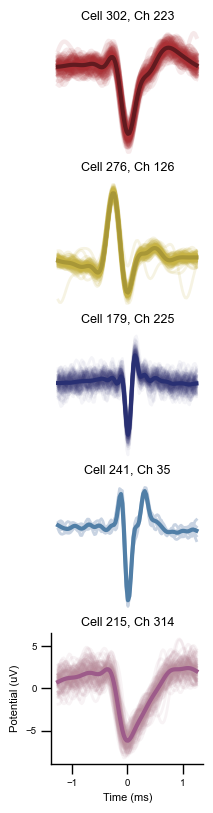

In [ ]:
%%time 

# get maximum amplitude channel ids
centered_len = 100
duration_ms = 2.5
ms_before = -duration_ms / 2
ms_after = duration_ms / 2

max_chids_s = ttools.get_template_extremum_channel(We_s, peak_sign="neg")
max_chids_e = ttools.get_template_extremum_channel(We_e, peak_sign="neg")

# setup plot parameters
N_SPIKES = 100

# setup figure colors
red = np.array([97, 26, 31, 100]) / 255
each_red = np.array([170, 48, 53, 100]) / 255
blue = np.array([41, 48, 115, 100]) / 255
each_blue = np.array([57, 58, 120, 100]) / 255
blue2 = np.array([81, 127, 167, 100]) / 255
each_blue2 = np.array([200, 211, 226, 100]) / 255
purple = np.array([157, 91, 138, 100]) / 255
each_purple = np.array([187, 142, 157, 100]) / 255

# setup plots
fig, ax = plt.subplots(5, 1, figsize=(2, 8))
time_axis = np.linspace(ms_before, ms_after, num=centered_len)

# plot regular spiking waveforms
sample_waveforms_1, mean_waveform_1, time_axis_1 = plot_centered_waveform(
    We_s,
    cell_id="302",
    nspike=N_SPIKES,
    centered_len=100,
    time_axis=time_axis,
    ax=ax[0],
    color_waveforms=each_red,
    color_template=red,
    max_chids=max_chids_s,
    alpha=0.1,
    linewidth=3,
)
ax[0].axis("off")  # remove

# plot positive waveforms
sample_waveforms_2, mean_waveform_2, time_axis_2 = plot_centered_waveform(
    We_s,
    cell_id="276",
    nspike=N_SPIKES,
    centered_len=100,
    time_axis=time_axis,
    ax=ax[1],
    color_waveforms=(199 / 255, 179 / 255, 68 / 255, 100 / 255),
    color_template=(168 / 255, 151 / 255, 55 / 255, 100 / 255),
    max_chids=max_chids_s,
    alpha=0.15,
)
ax[1].axis("off")  # remove

# plot fast spiking waveforms
sample_waveforms_3, mean_waveform_3, time_axis_3 = plot_centered_waveform(
    We_e,
    cell_id="179",
    nspike=N_SPIKES,
    centered_len=100,
    time_axis=time_axis,
    ax=ax[2],
    color_waveforms=each_blue,
    color_template=blue,
    max_chids=max_chids_e,
    alpha=0.05,
)
ax[2].axis("off")  # remove

# plot tri-phasic waveforms
sample_waveforms_4, mean_waveform_4, time_axis_4 = plot_centered_waveform(
    We_e,
    cell_id="241",
    nspike=N_SPIKES,
    centered_len=100,
    time_axis=time_axis,
    ax=ax[3],
    color_waveforms=each_blue2,
    color_template=blue2,
    max_chids=max_chids_e,
    alpha=1,
)
ax[3].axis("off")  # remove

# plot compound waveforms
sample_waveforms_5, mean_waveform_5, time_axis_5 = plot_centered_waveform(
    We_s,
    cell_id="215",
    nspike=N_SPIKES,
    centered_len=100,
    time_axis=time_axis,
    ax=ax[4],
    color_waveforms=each_purple,
    color_template=purple,
    max_chids=max_chids_s,
    alpha=0.1,
)
# ax[4].axis('off') # remove
plt.tight_layout(pad=0.1)

# save
# plt.savefig("figures/0_validation/5_spikes/fig3c_five_temporal_profiles.svg", dpi=300, **savefig_cfg)

## Source data

In [ ]:
# # format to dataframe
# df_1 = pd.DataFrame(sample_waveforms_1)
# df_1["mean"] = mean_waveform_1
# df_1["time"] = time_axis_1
# df_1 = pd.DataFrame(
#     {
#         "time": time_axis_1,
#         "mean": mean_waveform_1,
#         **{
#             f"waveform_{k}": sample_waveforms_1[:, k]
#             for k in range(sample_waveforms_1.shape[1])
#         },
#     }
# )
# # save to excel
# df_1.to_excel("figures/8_source_data/fig3c/fig3c_type_1.xlsx", index=False)


# # type 2
# df_2 = pd.DataFrame(sample_waveforms_2)
# df_2["mean"] = mean_waveform_2
# df_2["time"] = time_axis_2
# df_2 = pd.DataFrame(
#     {
#         "time": time_axis_2,
#         "mean": mean_waveform_2,
#         **{
#             f"waveform_{k}": sample_waveforms_2[:, k]
#             for k in range(sample_waveforms_2.shape[1])
#         },
#     }
# )
# # save to excel
# df_2.to_excel("figures/8_source_data/fig3c/fig3c_type_2.xlsx", index=False)

## Create source dataset

In [ ]:
# define all spike types
waveform_types = {
    1: (sample_waveforms_1, mean_waveform_1, time_axis_1),
    2: (sample_waveforms_2, mean_waveform_2, time_axis_2),
    3: (sample_waveforms_3, mean_waveform_3, time_axis_3),
    4: (sample_waveforms_4, mean_waveform_4, time_axis_4),
    5: (sample_waveforms_5, mean_waveform_5, time_axis_5),
}

# save all types
for type_id, (sample_waveforms, mean_waveform, time_axis) in waveform_types.items():

    # format to dataframe
    df = waveforms_to_df(sample_waveforms, mean_waveform, time_axis)

    # save to excel file
    df.to_excel(f"figures/8_source_data/fig3c/fig3c_type_{type_id}.xlsx", index=False)

## Load & plot saved data

Waveforms count: 100


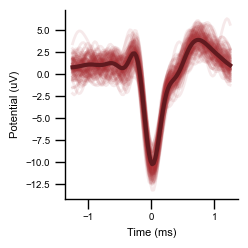

Waveforms count: 100


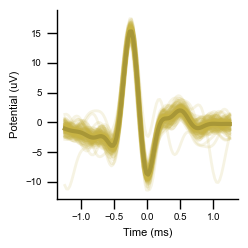

Waveforms count: 100


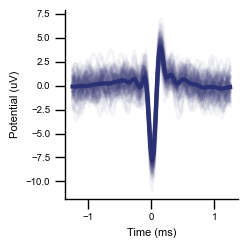

Waveforms count: 5


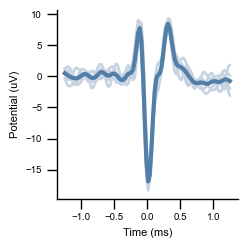

Waveforms count: 100


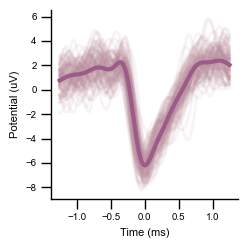

In [ ]:
# configure data to load
waveform_types = {
    1: {
        "path": "figures/8_source_data/fig3c/fig3c_type_1.xlsx",
        "color_waveforms": np.array([170, 48, 53, 100]) / 255,  # each_red
        "color_template": np.array([97, 26, 31, 100]) / 255,
    },  # red
    2: {
        "path": "figures/8_source_data/fig3c/fig3c_type_2.xlsx",
        "color_waveforms": (
            199 / 255,
            179 / 255,
            68 / 255,
            100 / 255,
        ),  # each_orange/yellow
        "color_template": (168 / 255, 151 / 255, 55 / 255, 100 / 255),
    },  # orange/yellow
    3: {
        "path": "figures/8_source_data/fig3c/fig3c_type_3.xlsx",
        "color_waveforms": np.array([57, 58, 120, 100]) / 255,  # each_blue
        "color_template": np.array([41, 48, 115, 100]) / 255,
    },  # blue
    4: {
        "path": "figures/8_source_data/fig3c/fig3c_type_4.xlsx",
        "color_waveforms": np.array([200, 211, 226, 100]) / 255,  # each_blue2
        "color_template": np.array([81, 127, 167, 100]) / 255,
    },  # blue2
    5: {
        "path": "figures/8_source_data/fig3c/fig3c_type_5.xlsx",
        "color_waveforms": np.array([187, 142, 157, 100]) / 255,  # each_purple
        "color_template": np.array([157, 91, 138, 100]) / 255,
    },  # purple
}

# setup figure parameters
alpha_per_type = {1: 0.1, 2: 0.15, 3: 0.05, 4: 1.0, 5: 0.1}
linewidth = 2

# load and plot
for type_id, cfg in waveform_types.items():

    # load data
    df = pd.read_excel(cfg["path"])

    # format data
    time_axis = df["time"].values
    mean_waveform = df["mean"].values
    sample_waveforms = np.array(
        [df[c] for c in df.columns if c.startswith("waveform_")]
    ).T

    # setup figure
    fig = plt.figure(figsize=(3, 3))
    ax = fig.add_subplot(1, 1, 1)

    # plot
    plot_wave(
        ax,
        sample_waveforms,
        mean_waveform,
        time_axis,
        cfg["color_waveforms"],
        cfg["color_template"],
        linewidth,
        alpha_per_type[type_id],
    )

    fig.tight_layout()
    plt.savefig(f"figures/8_source_data/fig3c/fig3c_type_{type_id}.svg", **savefig_cfg)
    plt.show()